# 일별 최대전력 EDA (2010-2025)

ARIMAX/SARIMAX 모델링 사전 진단.

## 목차
1. 데이터 로드 및 기본 통계
2. 종속변수 시계열 진단 — 정상성·ACF/PACF·계절성
3. 외생변수 개별 진단 — 분포·시계열·다중공선성
4. peak_mw ↔ 외생변수 관계 탐색
5. 2010-2024 학습 / 2025 홀드아웃 분포 비교

## 입력
- `data/processed/peak_mw_2010_2025.csv` — 종속변수 (5,844행)
- `data/processed/exog_daily_2010_2025.csv` — 외생변수 (5,844행 × 28개)

## 관련 문서
- `docs/independent_var.md` — 외생변수 정의
- `docs/research_log/2026-05-26_1015_외생변수_widetable_통합.md` — 통합 절차


## 0. Setup

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

# 한글 폰트 등록 (Noto Sans CJK ttc — matplotlib에는 "Noto Sans CJK JP" family로 노출되지만
# ttc 자체에 한글 글리프 포함). seaborn set_theme보다 먼저 rc 설정.
NOTO_PATH = Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc")
if NOTO_PATH.exists():
    font_manager.fontManager.addfont(str(NOTO_PATH))
KOR_FONT = "Noto Sans CJK JP"
mpl.rcParams["font.family"] = KOR_FONT
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["savefig.dpi"] = 130
sns.set_theme(style="whitegrid", rc={"font.family": KOR_FONT})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "data" / "processed"
print("ROOT:", ROOT)
print("matplotlib backend:", mpl.get_backend())
print("font family:", mpl.rcParams["font.family"])

ROOT: /home/jmlee/research/timeseries-final
matplotlib backend: module://matplotlib_inline.backend_inline
font family: ['Noto Sans CJK JP']


## 1. 데이터 로드 및 기본 통계

In [2]:
y = pd.read_csv(PROCESSED / "peak_mw_2010_2025.csv", encoding="utf-8-sig", parse_dates=["tm"])
X = pd.read_csv(PROCESSED / "exog_daily_2010_2025.csv", encoding="utf-8-sig", parse_dates=["tm"])
df = X.merge(y, on="tm", how="inner").set_index("tm").sort_index()
df.index.freq = "D"

print(f"y: {y.shape}, X: {X.shape}, merged: {df.shape}")
print(f"기간: {df.index.min().date()} ~ {df.index.max().date()}")
print(f"결측 합계: {df.isna().sum().sum()}")
df.head()

y: (5844, 2), X: (5844, 29), merged: (5844, 29)
기간: 2010-01-01 ~ 2025-12-31
결측 합계: 0


,ta_avg,ta_max,ta_min,hm_avg,ws_avg,rn_day,ss_day,ss_day_n_stations,cdd_18,hdd_18,...,heat_feels_th_2day_wrn,cold_th_2day_adv,cold_th_2day_wrn,dow,month,is_weekend,is_holiday,pop_total,ip_total,peak_mw
tm,,,,,,,,,,,,,,,,,,,,,
2010-01-01,-5.482130,-0.659303,-11.109710,52.481364,1.682431,0.003028,7.676279,16,0.0,23.482130,...,0,0,0,4,1,0,1,50515666,79.3,56391
2010-01-02,-0.807186,3.848668,-5.241714,71.105169,2.304041,0.693596,1.263227,16,0.0,18.807186,...,0,0,0,5,1,1,0,50515666,79.3,55470
2010-01-03,-3.767704,-0.047201,-7.394423,49.989562,1.921252,0.000000,8.237841,16,0.0,21.767704,...,0,0,0,6,1,1,0,50515666,79.3,55581
2010-01-04,-2.745978,0.711223,-5.122051,76.372243,2.816844,8.563877,0.709700,16,0.0,20.745978,...,0,0,0,0,1,0,0,50515666,79.3,66149
2010-01-05,-6.411501,-3.181076,-9.352543,64.526580,2.972885,0.470254,6.992638,16,0.0,24.411501,...,0,0,0,1,1,0,0,50515666,79.3,66901


In [3]:
EXOG_COLS = [c for c in df.columns if c != "peak_mw"]
DUMMY_COLS = ["is_weekend", "is_holiday", "heat_feels_th_2day_adv",
              "heat_feels_th_2day_wrn", "cold_th_2day_adv", "cold_th_2day_wrn"]
CONT_COLS = [c for c in EXOG_COLS if c not in DUMMY_COLS + ["dow", "month"]]

print(f"외생변수 {len(EXOG_COLS)}개")
print(f"  - 연속형: {len(CONT_COLS)}개")
print(f"  - 더미·범주형: {len(DUMMY_COLS) + 2}개 (dow, month 포함)")
print()
print("연속형 외생변수 요약:")
df[CONT_COLS].describe().T[["mean", "std", "min", "50%", "max"]].round(2)

외생변수 28개
  - 연속형: 20개
  - 더미·범주형: 8개 (dow, month 포함)

연속형 외생변수 요약:


,mean,std,min,50%,max
ta_avg,13.62,10.05,-12.82,14.56,31.75
ta_max,18.62,10.04,-8.55,20.20,37.96
ta_min,9.36,10.40,-16.66,9.77,27.55
hm_avg,66.51,13.04,27.70,67.14,97.47
ws_avg,2.12,0.69,0.88,1.96,7.77
rn_day,3.65,9.91,0.00,0.06,132.47
ss_day,6.48,3.47,0.00,7.21,13.38
ss_day_n_stations,15.97,0.18,14.00,16.00,16.00
cdd_18,2.32,3.47,0.00,0.00,13.75
hdd_18,6.70,7.60,0.00,3.44,30.82


## 2. 종속변수 시계열 진단

### 2.1 전체 시계열·연도별 분포

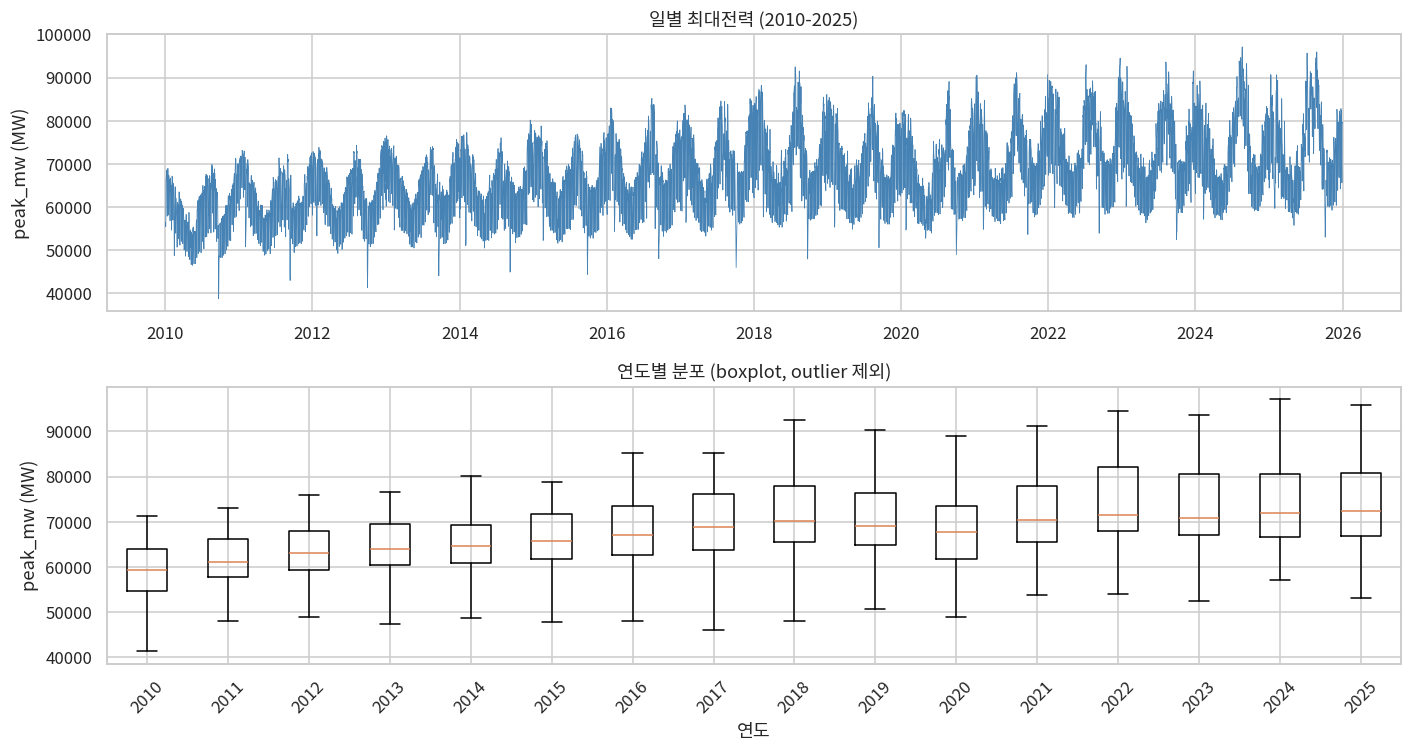

연도별 최댓값:
tm
2010    71308
2011    73137
2012    75987
2013    76522
2014    80154
2015    78790
2016    85183
2017    85133
2018    92478
2019    90314
2020    89091
2021    91141
2022    94509
2023    93615
2024    97115
2025    95951

전체 최대: 97,115 MW @ 2024-08-20
전체 최소: 38,764 MW @ 2010-09-22


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

axes[0].plot(df.index, df["peak_mw"], lw=0.5, color="steelblue")
axes[0].set_title("일별 최대전력 (2010-2025)")
axes[0].set_ylabel("peak_mw (MW)")

yearly = df["peak_mw"].groupby(df.index.year)
axes[1].boxplot([yearly.get_group(y).values for y in sorted(yearly.groups)],
                tick_labels=sorted(yearly.groups), showfliers=False)
axes[1].set_title("연도별 분포 (boxplot, outlier 제외)")
axes[1].set_xlabel("연도")
axes[1].set_ylabel("peak_mw (MW)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("연도별 최댓값:")
print(yearly.max().to_string())
print()
print(f"전체 최대: {df['peak_mw'].max():,} MW @ {df['peak_mw'].idxmax().date()}")
print(f"전체 최소: {df['peak_mw'].min():,} MW @ {df['peak_mw'].idxmin().date()}")

### 2.2 정상성 검정 — ADF / KPSS

- **ADF**: H0 = 단위근(비정상) → p < 0.05면 정상
- **KPSS**: H0 = 정상 → p < 0.05면 비정상

두 검정을 함께 보고 차분 차수 d를 판단.

In [5]:
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity_report(series: pd.Series, label: str) -> dict:
    s = series.dropna()
    adf_stat, adf_p, *_ = adfuller(s, autolag="AIC")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
    return {
        "label": label,
        "n": len(s),
        "ADF stat": adf_stat,
        "ADF p": adf_p,
        "ADF 결론": "정상" if adf_p < 0.05 else "비정상",
        "KPSS stat": kpss_stat,
        "KPSS p": kpss_p,
        "KPSS 결론": "정상" if kpss_p >= 0.05 else "비정상",
    }

reports = [
    stationarity_report(df["peak_mw"], "원본"),
    stationarity_report(df["peak_mw"].diff(), "1차 차분"),
    stationarity_report(df["peak_mw"].diff().diff(7), "1차 + 주간 차분"),
    stationarity_report(np.log(df["peak_mw"]), "log"),
    stationarity_report(np.log(df["peak_mw"]).diff(), "log + 1차 차분"),
]
pd.DataFrame(reports).round(4)

,label,n,ADF stat,ADF p,ADF 결론,KPSS stat,KPSS p,KPSS 결론
0,원본,5844,-7.0085,0.0,정상,5.6212,0.01,비정상
1,1차 차분,5843,-11.8000,0.0,정상,0.0053,0.10,정상
2,1차 + 주간 차분,5836,-24.1759,0.0,정상,0.0085,0.10,정상
3,log,5844,-6.8315,0.0,정상,5.7450,0.01,비정상
4,log + 1차 차분,5843,-11.9217,0.0,정상,0.0054,0.10,정상


### 2.3 STL 분해 — 추세·주간 계절·잔차

period=7 (주간) 우선. 연간 계절성은 STL을 365로 돌리기엔 비용이 커서
별도 항목에서 월별 분포로 확인.

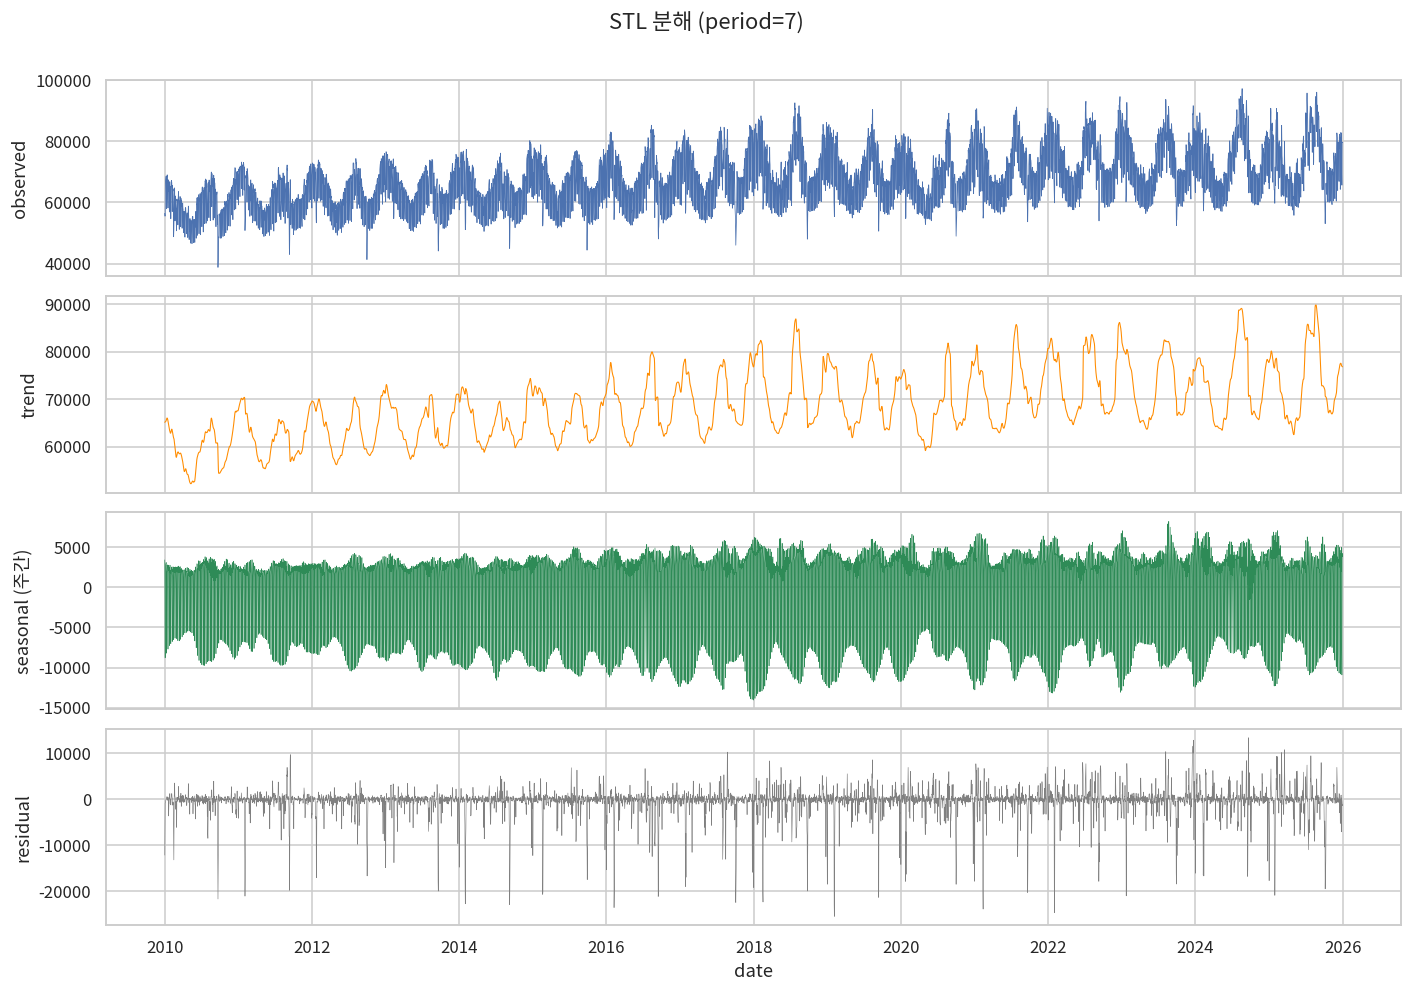

주간 계절 진폭(peak-trough): 22,290 MW
평균 peak_mw 대비 진폭 비율: 32.74%


In [6]:
from statsmodels.tsa.seasonal import STL

stl = STL(df["peak_mw"], period=7, robust=True).fit()
fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
axes[0].plot(df.index, stl.observed, lw=0.5); axes[0].set_ylabel("observed")
axes[1].plot(df.index, stl.trend, lw=0.7, color="darkorange"); axes[1].set_ylabel("trend")
axes[2].plot(df.index, stl.seasonal, lw=0.4, color="seagreen"); axes[2].set_ylabel("seasonal (주간)")
axes[3].plot(df.index, stl.resid, lw=0.4, color="gray"); axes[3].set_ylabel("residual")
axes[3].set_xlabel("date")
fig.suptitle("STL 분해 (period=7)", y=1.0)
plt.tight_layout()
plt.show()

print(f"주간 계절 진폭(peak-trough): {stl.seasonal.max() - stl.seasonal.min():,.0f} MW")
print(f"평균 peak_mw 대비 진폭 비율: {(stl.seasonal.max() - stl.seasonal.min()) / df['peak_mw'].mean() * 100:.2f}%")

### 2.4 주간·월간·요일 계절성

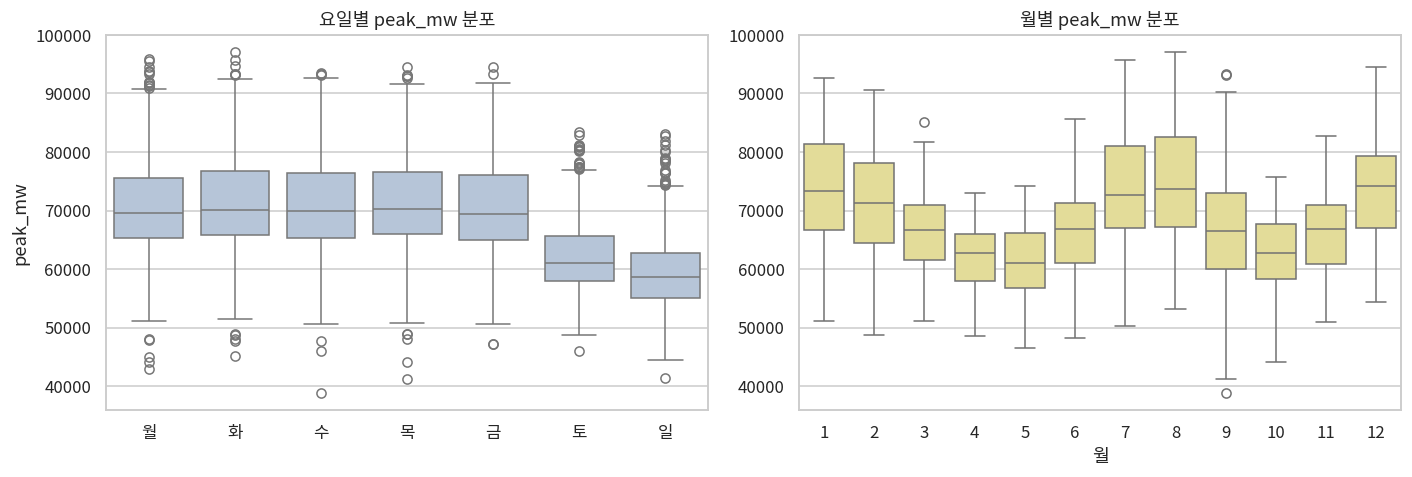

요일별 중앙값 (MW):
dow
월    69629.0
화    70133.0
수    69845.0
목    70238.0
금    69401.0
토    61037.0
일    58640.0

주말(토일) vs 평일 중앙값 차이: 10,006 MW

월별 중앙값 (MW):
month
1     73339.0
2     71354.0
3     66702.0
4     62694.0
5     60955.0
6     66765.0
7     72588.0
8     73696.0
9     66544.0
10    62823.0
11    66918.0
12    74158.0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

dow_names = ["월", "화", "수", "목", "금", "토", "일"]
dow_med = df.groupby("dow")["peak_mw"].median()
sns.boxplot(x=df["dow"].map(lambda i: dow_names[i]), y=df["peak_mw"],
            order=dow_names, ax=axes[0], color="lightsteelblue")
axes[0].set_title("요일별 peak_mw 분포")
axes[0].set_xlabel(""); axes[0].set_ylabel("peak_mw")

sns.boxplot(x="month", y="peak_mw", data=df.reset_index(), ax=axes[1], color="khaki")
axes[1].set_title("월별 peak_mw 분포")
axes[1].set_xlabel("월"); axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

print("요일별 중앙값 (MW):")
print(dow_med.rename(index=dict(enumerate(dow_names))).round(0).to_string())
print(f"\n주말(토일) vs 평일 중앙값 차이: {dow_med.iloc[:5].median() - dow_med.iloc[5:].median():,.0f} MW")
print(f"\n월별 중앙값 (MW):")
print(df.groupby("month")["peak_mw"].median().round(0).to_string())

### 2.5 ACF / PACF — ARIMA 차수 후보

원본 + 차분 시리즈 비교. lag 40까지(주간 5주분).

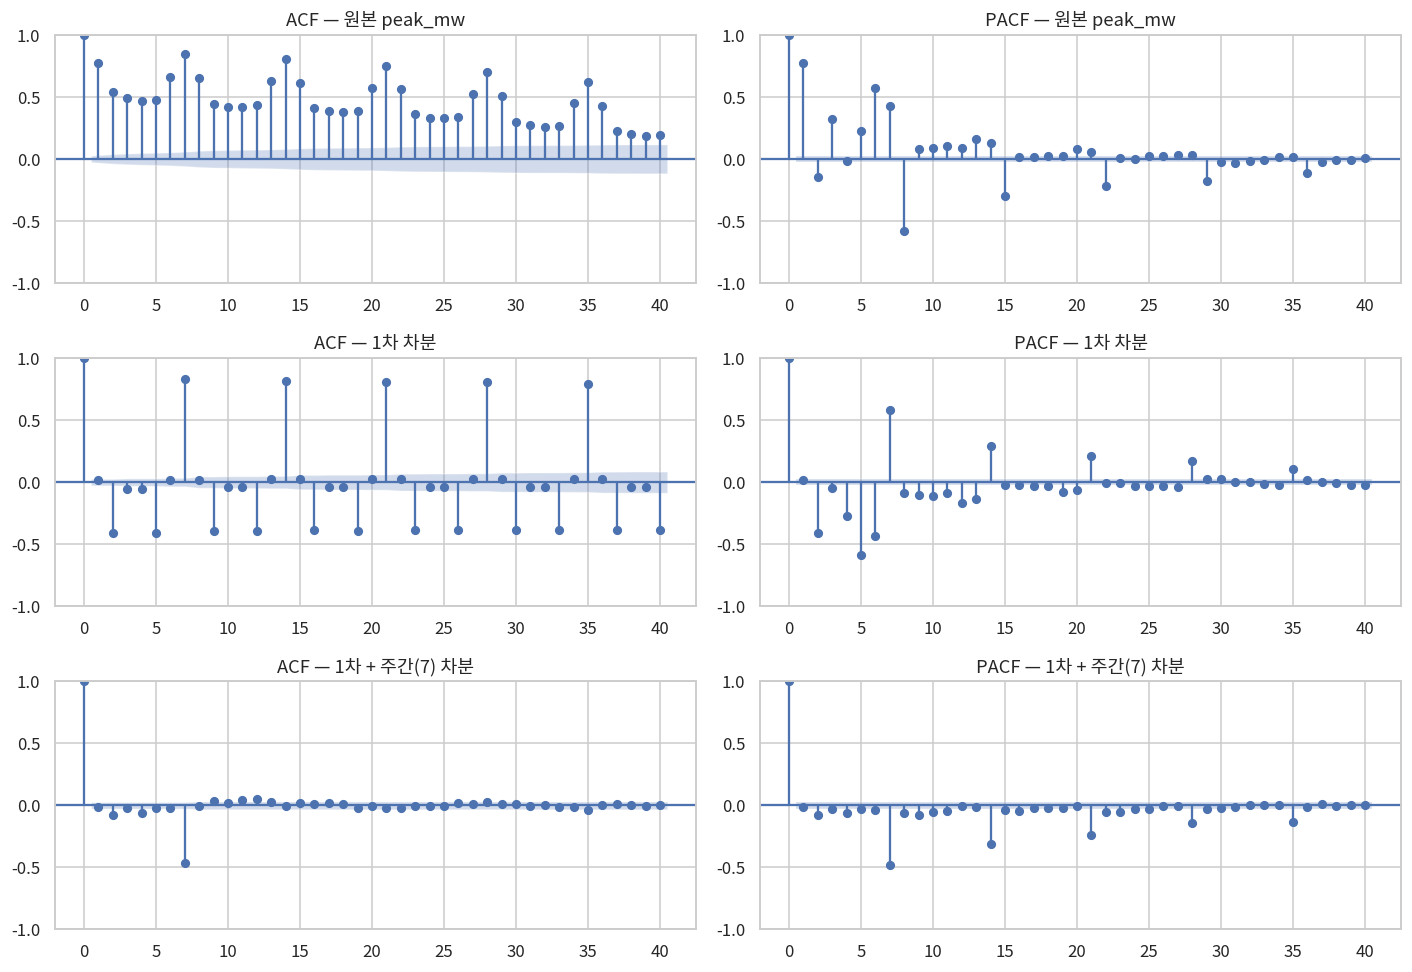

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(3, 2, figsize=(13, 9))

series_set = [
    ("원본 peak_mw", df["peak_mw"]),
    ("1차 차분", df["peak_mw"].diff().dropna()),
    ("1차 + 주간(7) 차분", df["peak_mw"].diff().diff(7).dropna()),
]
for i, (label, s) in enumerate(series_set):
    plot_acf(s, lags=40, ax=axes[i, 0], title=f"ACF — {label}")
    plot_pacf(s, lags=40, ax=axes[i, 1], method="ywm", title=f"PACF — {label}")
plt.tight_layout()
plt.show()

## 3. 외생변수 개별 진단

### 3.1 연속형 외생변수 — 시계열 그리드

장기 추세·구조변화·이상치 탐지.

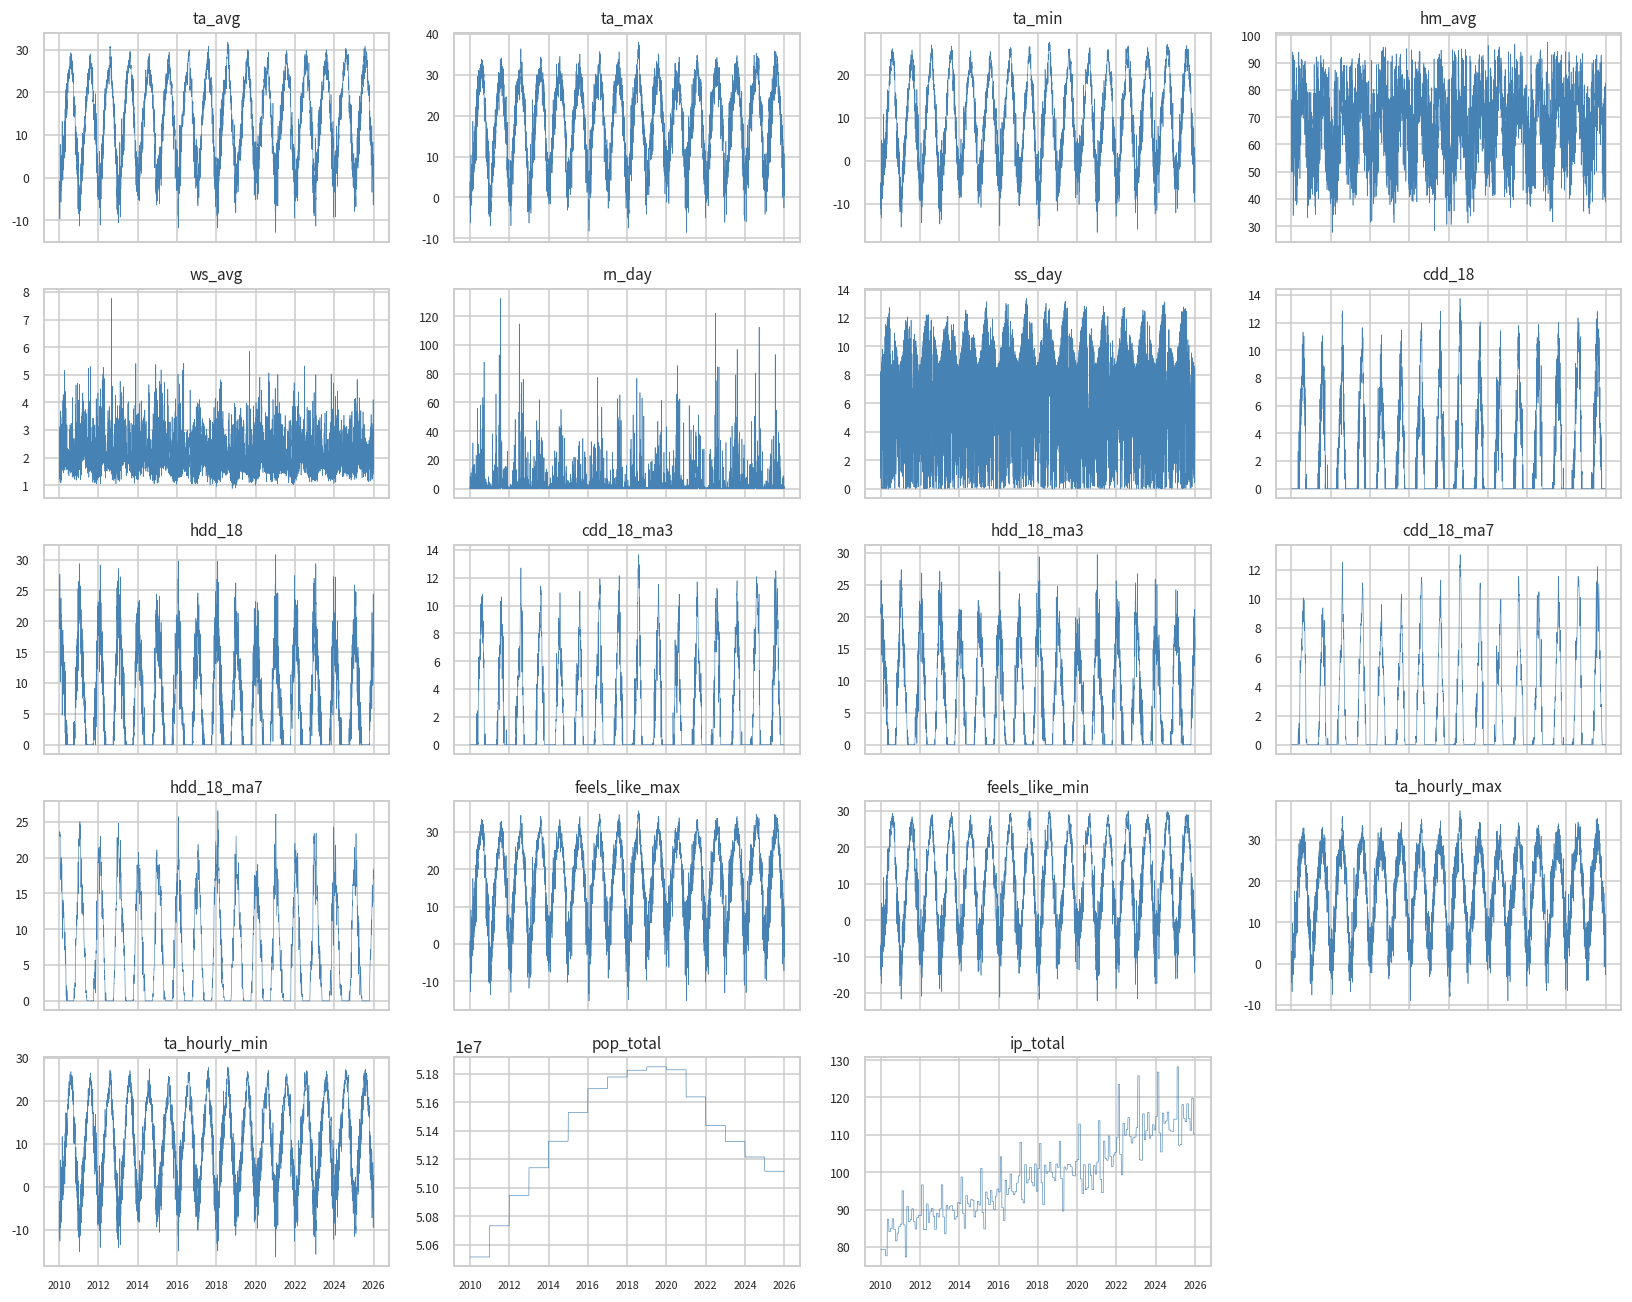

In [9]:
cont = [c for c in CONT_COLS if c != "ss_day_n_stations"]
ncols = 4
nrows = int(np.ceil(len(cont) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 2.4 * nrows), sharex=True)
for ax, col in zip(axes.ravel(), cont):
    ax.plot(df.index, df[col], lw=0.4, color="steelblue")
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis="x", labelsize=7)
    ax.tick_params(axis="y", labelsize=8)
for ax in axes.ravel()[len(cont):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 3.2 상관행렬 — 외생변수 간 + peak_mw

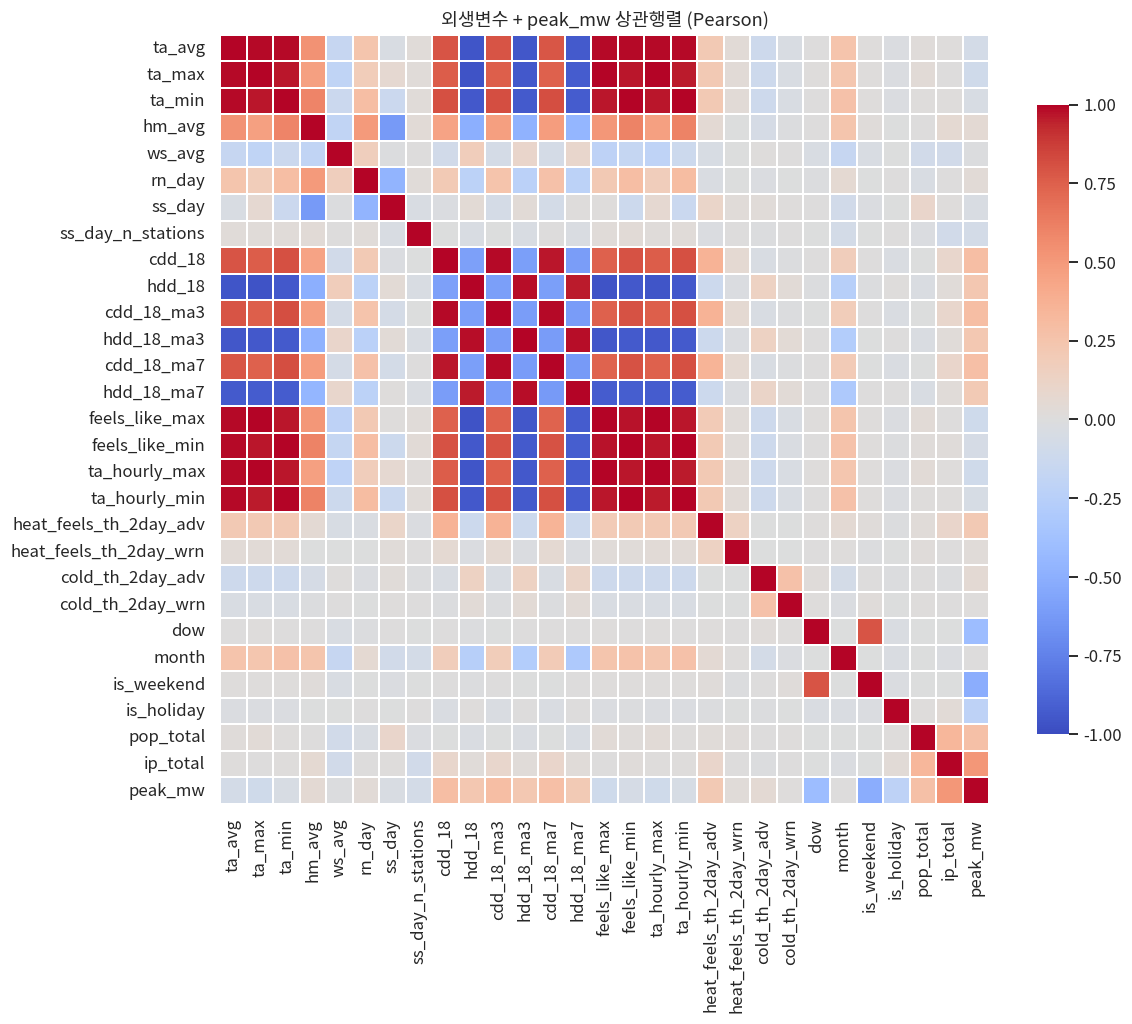

peak_mw와의 절대상관 상위 12개:
ip_total                  0.515
is_weekend               -0.510
dow                      -0.414
cdd_18                    0.296
cdd_18_ma3                0.294
cdd_18_ma7                0.285
pop_total                 0.280
hdd_18                    0.232
hdd_18_ma3                0.224
is_holiday               -0.216
heat_feels_th_2day_adv    0.215
hdd_18_ma7                0.210


In [10]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(11, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=False, square=True, linewidths=0.3, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("외생변수 + peak_mw 상관행렬 (Pearson)")
plt.tight_layout()
plt.show()

print("peak_mw와의 절대상관 상위 12개:")
print(corr["peak_mw"].drop("peak_mw").reindex(corr["peak_mw"].drop("peak_mw").abs().sort_values(ascending=False).index).head(12).round(3).to_string())

### 3.3 다중공선성 — VIF

설계 의도상 cdd/hdd 계열(원본·ma3·ma7)은 강한 상관을 가질 수밖에 없음.
실제로 얼마나 심한지 VIF로 확인하고, 모델링 단계에서 어느 lag만 살릴지 판단 근거를 둠.

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_cols = [c for c in CONT_COLS if c != "ss_day_n_stations"]
Xv = df[vif_cols].copy()
Xv = (Xv - Xv.mean()) / Xv.std()
Xv = Xv.assign(const=1.0)

vif = pd.DataFrame({
    "var": vif_cols,
    "VIF": [variance_inflation_factor(Xv.values, i) for i in range(len(vif_cols))],
}).sort_values("VIF", ascending=False).reset_index(drop=True)
vif.round(2)

/home/jmlee/research/timeseries-final/.venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,var,VIF
0,ta_avg,inf
1,cdd_18,inf
2,hdd_18,inf
3,ta_min,1835.84
4,ta_max,1696.60
5,ta_hourly_max,1674.11
6,ta_hourly_min,1533.55
7,feels_like_min,254.34
8,feels_like_max,179.43
9,cdd_18_ma3,101.22


### 3.4 더미·범주형 — 발효일수·peak_mw 차이

In [12]:
dummy_summary = []
for col in DUMMY_COLS:
    on = df.loc[df[col] == 1, "peak_mw"]
    off = df.loc[df[col] == 0, "peak_mw"]
    dummy_summary.append({
        "변수": col,
        "발효일수(=1)": int(df[col].sum()),
        "비율(%)": df[col].mean() * 100,
        "발효일 mean peak_mw": on.mean() if len(on) else np.nan,
        "비발효일 mean peak_mw": off.mean(),
        "차이": (on.mean() - off.mean()) if len(on) else np.nan,
    })
pd.DataFrame(dummy_summary).round(0)

,변수,발효일수(=1),비율(%),발효일 mean peak_mw,비발효일 mean peak_mw,차이
0,is_weekend,1670,29.0,60751.0,71011.0,-10260.0
1,is_holiday,273,5.0,59185.0,68515.0,-9330.0
2,heat_feels_th_2day_adv,105,2.0,82538.0,67815.0,14723.0
3,heat_feels_th_2day_wrn,2,0.0,81936.0,68075.0,13861.0
4,cold_th_2day_adv,14,0.0,76956.0,68058.0,8898.0
5,cold_th_2day_wrn,1,0.0,74232.0,68078.0,6154.0


## 4. peak_mw ↔ 주요 외생변수 관계 탐색

### 4.1 기온-부하 U자 곡선 (월 색분)

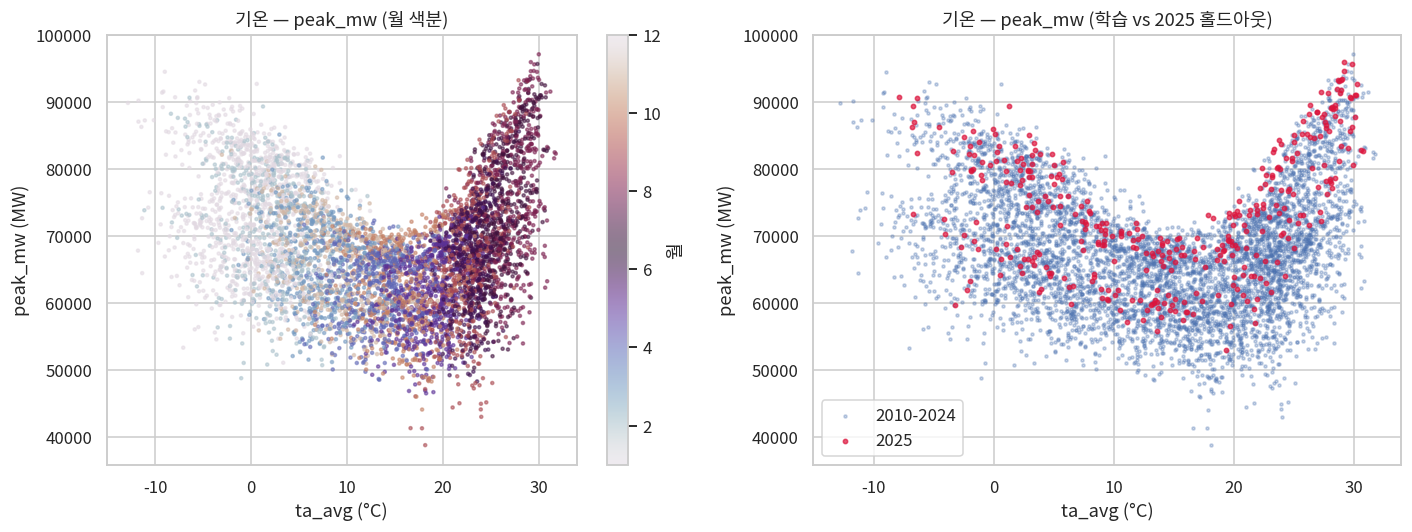

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

scatter = axes[0].scatter(df["ta_avg"], df["peak_mw"], c=df["month"],
                          cmap="twilight", s=4, alpha=0.55)
axes[0].set_xlabel("ta_avg (°C)"); axes[0].set_ylabel("peak_mw (MW)")
axes[0].set_title("기온 — peak_mw (월 색분)")
fig.colorbar(scatter, ax=axes[0], label="월")

# 학습/평가 분리: 2010-2024 vs 2025
train = df.loc["2010":"2024"]
test = df.loc["2025"]
axes[1].scatter(train["ta_avg"], train["peak_mw"], s=4, alpha=0.3, label="2010-2024")
axes[1].scatter(test["ta_avg"], test["peak_mw"], s=8, alpha=0.7, label="2025", color="crimson")
axes[1].set_xlabel("ta_avg (°C)"); axes[1].set_ylabel("peak_mw (MW)")
axes[1].set_title("기온 — peak_mw (학습 vs 2025 홀드아웃)")
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.2 주요 외생변수 — peak_mw 산점도 + lowess

/home/jmlee/research/timeseries-final/.venv/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


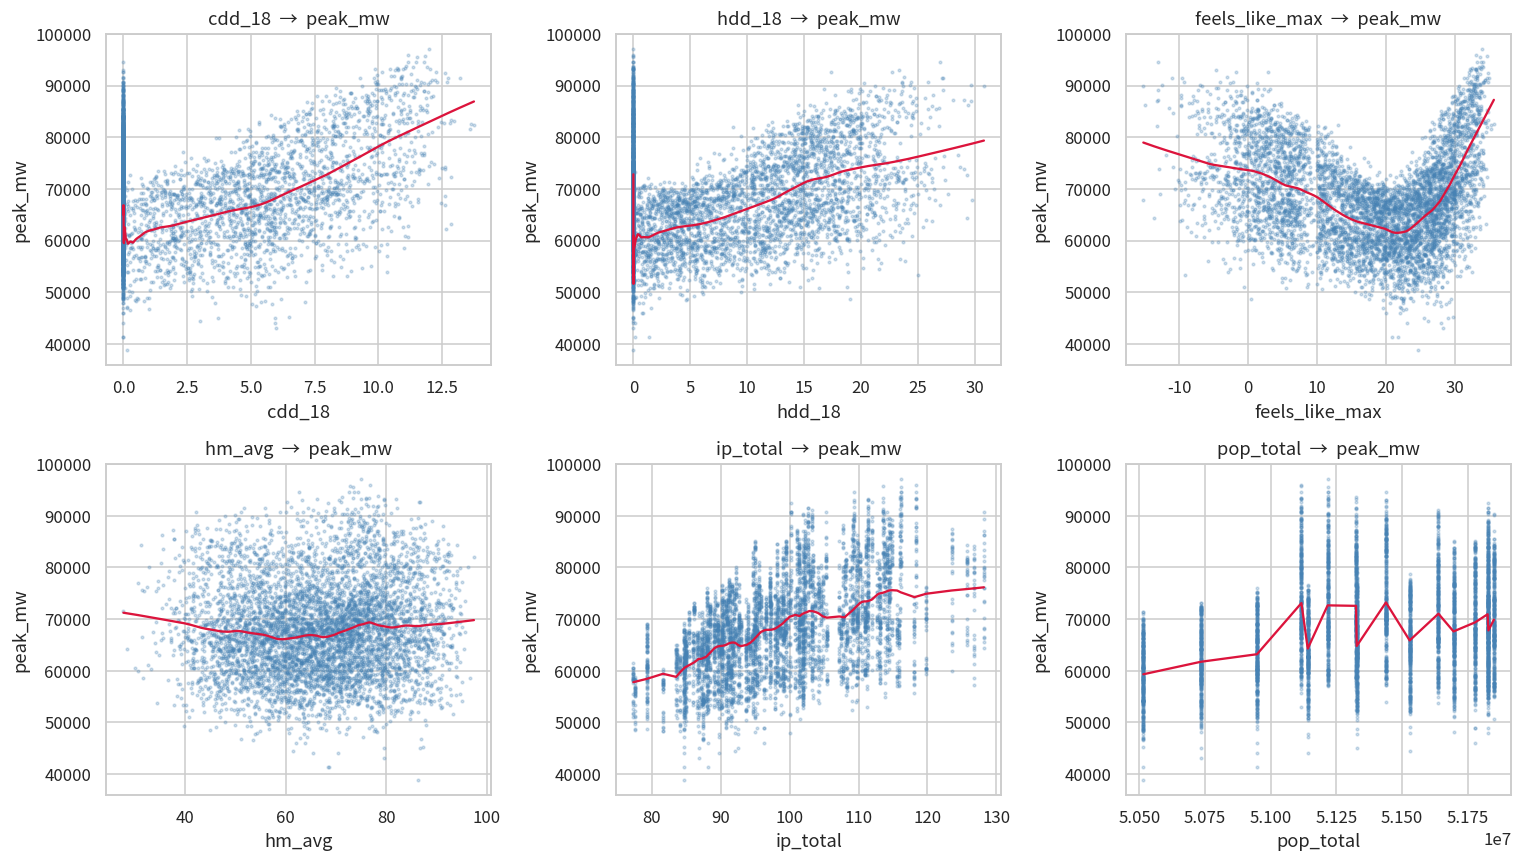

In [14]:
from statsmodels.nonparametric.smoothers_lowess import lowess

focus = ["cdd_18", "hdd_18", "feels_like_max", "hm_avg", "ip_total", "pop_total"]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), focus):
    ax.scatter(df[col], df["peak_mw"], s=3, alpha=0.25, color="steelblue")
    sm = lowess(df["peak_mw"], df[col], frac=0.15, return_sorted=True)
    ax.plot(sm[:, 0], sm[:, 1], color="crimson", lw=1.5)
    ax.set_title(f"{col}  →  peak_mw")
    ax.set_xlabel(col); ax.set_ylabel("peak_mw")
plt.tight_layout()
plt.show()

### 4.3 교차상관 (CCF) — peak_mw와 외생변수 시차 영향

음의 lag(외생변수가 선행), 양의 lag(외생변수가 후행).
일별로 30일까지.

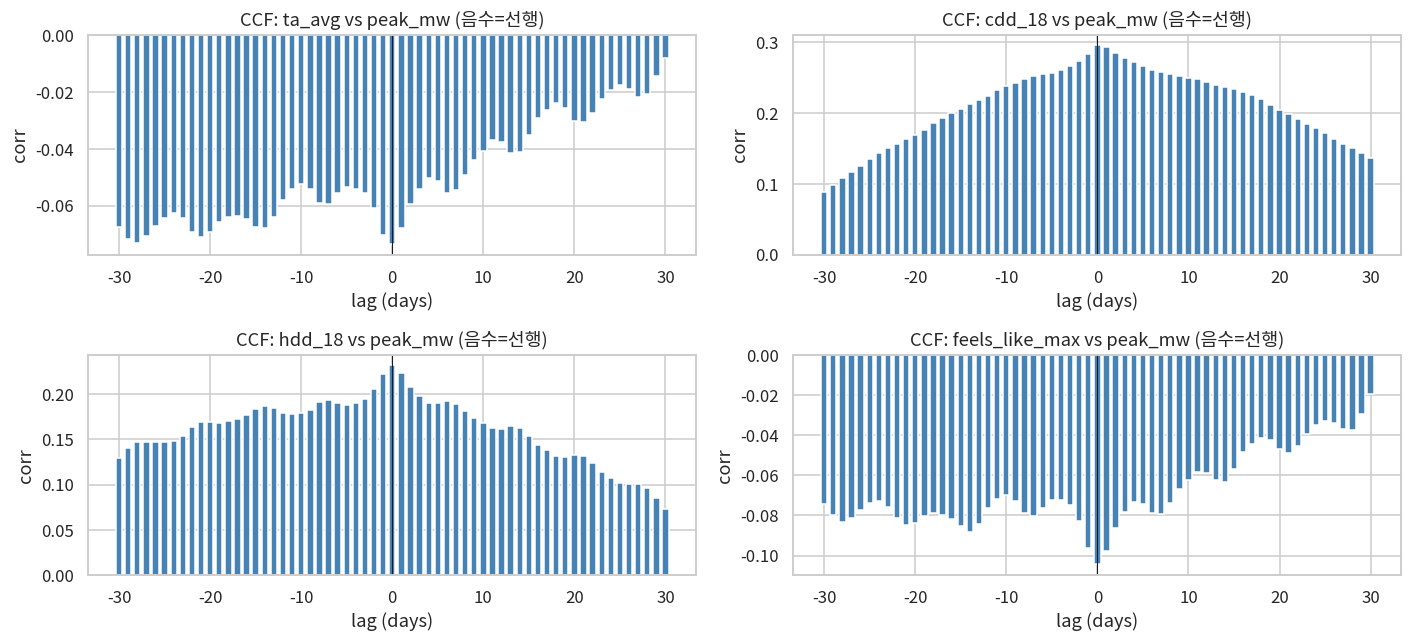

In [15]:
def ccf_lagged(x: pd.Series, y: pd.Series, max_lag: int = 30) -> pd.Series:
    x = (x - x.mean()) / x.std()
    y = (y - y.mean()) / y.std()
    return pd.Series(
        {k: x.shift(k).corr(y) for k in range(-max_lag, max_lag + 1)},
        name=x.name,
    )

ccf_targets = ["ta_avg", "cdd_18", "hdd_18", "feels_like_max"]
fig, axes = plt.subplots(2, 2, figsize=(13, 6))
for ax, col in zip(axes.ravel(), ccf_targets):
    s = ccf_lagged(df[col], df["peak_mw"], 30)
    ax.bar(s.index, s.values, width=0.7, color="steelblue")
    ax.axvline(0, color="k", lw=0.7)
    ax.set_title(f"CCF: {col} vs peak_mw (음수=선행)")
    ax.set_xlabel("lag (days)"); ax.set_ylabel("corr")
plt.tight_layout()
plt.show()

## 5. 2010-2024 학습 / 2025 홀드아웃 프리뷰

### 5.1 분할 크기·분포 비교

In [16]:
train = df.loc["2010":"2024"]
test = df.loc["2025"]
print(f"학습 (2010-2024): {len(train):,}행")
print(f"평가 (2025):       {len(test):,}행")
print()

split_stats = pd.DataFrame({
    "train_mean": train.mean(numeric_only=True),
    "test_mean": test.mean(numeric_only=True),
    "train_std": train.std(numeric_only=True),
    "test_std": test.std(numeric_only=True),
})
split_stats["mean_shift_%"] = ((split_stats["test_mean"] - split_stats["train_mean"]) / split_stats["train_mean"].abs() * 100).round(1)
split_stats.round(2).sort_values("mean_shift_%", key=abs, ascending=False).head(15)

학습 (2010-2024): 5,479행
평가 (2025):       365행



,train_mean,test_mean,train_std,test_std,mean_shift_%
heat_feels_th_2day_adv,0.02,0.04,0.13,0.20,150.2
cold_th_2day_wrn,0.00,0.00,0.01,0.00,-100.0
cold_th_2day_adv,0.00,0.00,0.05,0.00,-100.0
heat_feels_th_2day_wrn,0.00,0.00,0.02,0.00,-100.0
cdd_18,2.29,2.76,3.43,3.95,20.3
cdd_18_ma3,2.29,2.76,3.40,3.91,20.3
cdd_18_ma7,2.29,2.76,3.36,3.86,20.3
ip_total,97.70,114.64,9.89,5.51,17.3
is_holiday,0.05,0.05,0.21,0.22,12.3
peak_mw,67713.04,73577.71,8953.79,9468.62,8.7


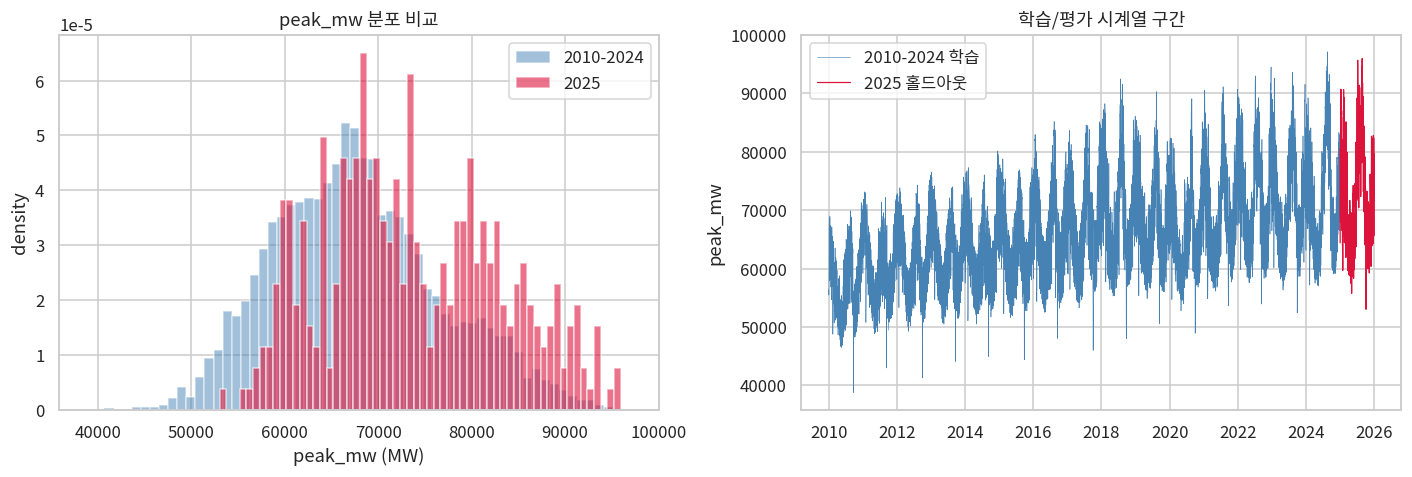

train peak_mw: mean=67,713, max=97,115
test  peak_mw: mean=73,578, max=95,951
test mean / train mean - 1 = +8.66%


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(train["peak_mw"], bins=60, alpha=0.5, label="2010-2024", density=True, color="steelblue")
axes[0].hist(test["peak_mw"], bins=60, alpha=0.6, label="2025", density=True, color="crimson")
axes[0].set_title("peak_mw 분포 비교")
axes[0].set_xlabel("peak_mw (MW)"); axes[0].set_ylabel("density")
axes[0].legend()

axes[1].plot(train.index, train["peak_mw"], lw=0.4, color="steelblue", label="2010-2024 학습")
axes[1].plot(test.index, test["peak_mw"], lw=0.8, color="crimson", label="2025 홀드아웃")
axes[1].set_title("학습/평가 시계열 구간")
axes[1].set_ylabel("peak_mw"); axes[1].legend()

plt.tight_layout()
plt.show()

print(f"train peak_mw: mean={train['peak_mw'].mean():,.0f}, max={train['peak_mw'].max():,}")
print(f"test  peak_mw: mean={test['peak_mw'].mean():,.0f}, max={test['peak_mw'].max():,}")
print(f"test mean / train mean - 1 = {test['peak_mw'].mean() / train['peak_mw'].mean() - 1:+.2%}")

## 6. 요약

이 노트북에서 도출한 ARIMAX/SARIMAX 모델링 입력은
`docs/research_log/2026-05-26_*EDA*.md`에 정리.

핵심 사항:
- 차분 차수, 계절 주기, 후보 외생변수 셋, 다중공선성 처리 방안.